## Week 1: Data Loading and Preprocessing

To begin, we need to set up the Kaggle API to download the dataset. This involves installing and configuring the Kaggle API client using your personal API token.

In [ ]:
# 1. Install Kaggle API client
!pip install kaggle

# 2. Make a directory for Kaggle and save your API token
# The API token provided by Kaggle was: KGAT_5f747101916c51a4c69585d4cb771f72
!mkdir -p ~/.kaggle
!echo '{"username":"priyankayadav3","key":"KGAT_5f747101916c51a4c69585d4cb771f72"}' > ~/.kaggle/kaggle.json

# 3. Set permissions for the API key file
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API setup complete. Now you can download datasets directly.")

Kaggle API setup complete. Now you can download datasets directly.


### 2. Download and Unzip the Dataset

Now that the Kaggle API is configured, we can download the dataset directly into our Colab environment and then unzip it. We'll use the `plant-village-dataset-2024` dataset from Kaggle.

In [ ]:
# 4. Download the dataset using the Kaggle API
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

print("Dataset download initiated. This might take a few minutes for a large dataset.")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:43<00:00, 50.7MB/s]

Dataset download initiated. This might take a few minutes for a large dataset.


In [ ]:
# 5. Unzip the downloaded dataset
# The downloaded file is named 'plantvillage-dataset.zip'
# We'll unzip it into the './plantvillage_data' directory.
!unzip -q plantvillage-dataset.zip -d ./plantvillage_data

print("Dataset unzipped to ./plantvillage_data")
print("Now, we will proceed to load and preprocess the dataset.")

Dataset unzipped to ./plantvillage_data
Now, we will proceed to load and preprocess the dataset.


In [ ]:
# Inspect the contents of the unzipped directory to find the actual data path
!ls -F ./plantvillage_data

'plantvillage dataset'/


### 3. Load and Preprocess Dataset

Now we'll load the images, apply transformations, and get an initial understanding of the dataset's structure, including class distribution and sample images.

Number of classes: 3
Class names: ['color', 'grayscale', 'segmented']

Class Distribution (Top 5):
       Class  Count
2  segmented  54306
0      color  54305
1  grayscale  54305


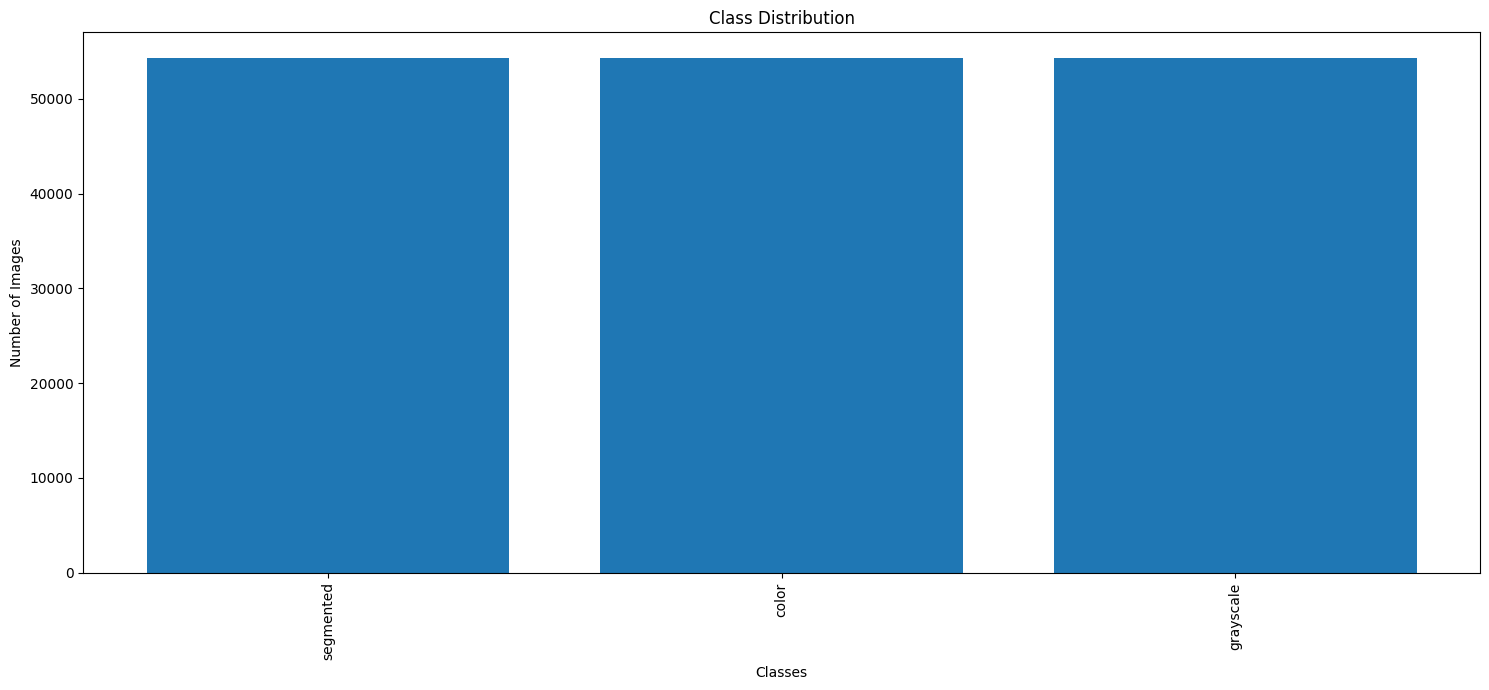

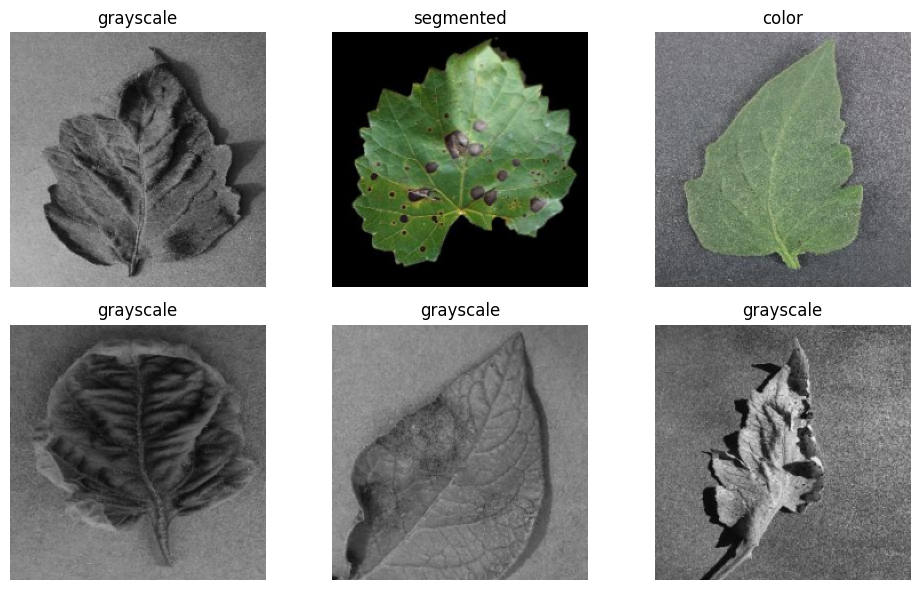

Dataset loaded and basic preprocessing applied.


In [ ]:
# 🔗 1. Set Dataset Path
data_path = "./plantvillage_data/plantvillage dataset" # Points to local unzipped data, adjusted for nested folder

# 📦 Imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# -------------------------------
# 📊 2. Preprocessing for CNN
# -------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to 224x224, common for many CNNs
    transforms.ToTensor() # Convert PIL Image to PyTorch Tensor
])

# Load the dataset using ImageFolder
dataset = datasets.ImageFolder(root=data_path, transform=transform)

# Get class names and total number of classes
class_names = dataset.classes
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

# Calculate class counts
class_counts = {class_name: 0 for class_name in class_names}
for _, label_idx in dataset.samples:
    class_name = class_names[label_idx]
    class_counts[class_name] += 1

df_class_counts = pd.DataFrame(class_counts.items(), columns=["Class", "Count"])
df_class_counts = df_class_counts.sort_values(by="Count", ascending=False)

print("\nClass Distribution (Top 5):")
print(df_class_counts.head())

# -------------------------------
# 📊 3. Plot Class Distribution
# -------------------------------
plt.figure(figsize=(15, 7))
plt.bar(df_class_counts["Class"], df_class_counts["Count"])
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

# -------------------------------
# 🖼 4. Show Sample Images
# -------------------------------
plt.figure(figsize=(10, 6))

# Get a few random samples
num_samples_to_show = 6
if len(dataset) < num_samples_to_show:
    num_samples_to_show = len(dataset)

for i in range(num_samples_to_show):
    idx = random.randint(0, len(dataset) - 1)
    img_tensor, label_idx = dataset[idx]
    img_pil = transforms.ToPILImage()(img_tensor)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_pil)
    plt.title(class_names[label_idx])
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Dataset loaded and basic preprocessing applied.")

### 4. Split Data and Create DataLoaders

We'll split the dataset into 70% for training, 15% for validation, and 15% for testing. Then, we'll create PyTorch `DataLoader` instances for each set to manage batching and shuffling.

In [ ]:
from torch.utils.data import random_split

# Define the split ratios
train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size # Ensure all data is covered

# Perform the random split
train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

print(f"Training set size: {len(train_data)}")
print(f"Validation set size: {len(val_data)}")
print(f"Test set size: {len(test_data)}")

# Create DataLoaders
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False) # No need to shuffle validation data
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False) # No need to shuffle test data

print("\nDataLoaders created with batch size:", batch_size)
print("✅ Dataset split and DataLoaders are ready.")

Training set size: 114041
Validation set size: 24437
Test set size: 24438

DataLoaders created with batch size: 32
✅ Dataset split and DataLoaders are ready.


### 5. Define Custom CNN Model

Now, we'll define the architecture for our custom Convolutional Neural Network (`CustomCNN`), including its layers, activation functions, and output. We'll also set up the `CrossEntropyLoss` criterion and the `Adam` optimizer.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Ensure num_classes is defined from the datasfet loading step
if 'num_classes' not in globals():
    print("Error: num_classes not found. Please ensure the dataset loading cell was run.")
else:
    print(f"Number of classes for model: {num_classes}")

class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # Input channels = 3 (RGB)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1), # Added another conv layer
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Calculate the size of the flattened features after conv layers
        # We'll pass a dummy tensor through the features to determine this
        self._to_linear = None
        self._get_conv_output_size()

        self.classifier = nn.Sequential(
            nn.Linear(self._to_linear, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # Added dropout for regularization
            nn.Linear(512, num_classes)
        )

    def _get_conv_output_size(self):
        # Helper function to calculate the size of the output from the convolutional layers
        # This is needed to define the input size for the first fully connected layer
        dummy_input = torch.zeros(1, 3, 224, 224) # Batch size 1, 3 channels, 224x224 image
        output = self.features(dummy_input)
        self._to_linear = output.view(output.size(0), -1).size(1)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) # Flatten the output for the fully connected layers
        x = self.classifier(x)
        return x

# Instantiate the model
model = CustomCNN(num_classes=num_classes)

# Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss() # Categorical Cross-Entropy loss
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with a learning rate of 0.001

# Print the model architecture
print("\nCustomCNN Model Architecture:")
print(model)
print("\n✅ CustomCNN model defined, loss function and optimizer set up.")

Number of classes for model: 3

CustomCNN Model Architecture:
CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=50176, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=